Install & Import Libraries

In [91]:
# Install libraries (if needed)
!pip install pandas numpy matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

Upload Dataset in Colab

In [92]:
# from google.colab import files
# uploaded = files.upload()

In [93]:
# Read dataset
df = pd.read_csv("sales_06_FY2020-21 copy.csv", low_memory=False)

# Show first rows
df.head()

,order_id,order_date,status,item_id,sku,qty_ordered,price,value,discount_amount,total,...,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name,Discount_Percent
0,100354678,2020-10-01,received,574772.0,oasis_Oasis-064-36,21.0,89.9,1798.0,0.0,1798.0,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
1,100354678,2020-10-01,received,574774.0,Fantastic_FT-48,11.0,19.0,190.0,0.0,190.0,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
2,100354680,2020-10-01,complete,574777.0,mdeal_DMC-610-8,9.0,149.9,1199.2,0.0,1199.2,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
3,100354680,2020-10-01,complete,574779.0,oasis_Oasis-061-36,9.0,79.9,639.2,0.0,639.2,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
4,100367357,2020-11-13,received,595185.0,MEFNAR59C38B6CA08CD,2.0,99.9,99.9,0.0,99.9,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0


Dataset Inspection

In [94]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("Columns:")
print(df.columns)

# Data types
df.info()

Dataset Shape: (286392, 36)
Columns:
Index(['order_id', 'order_date', 'status', 'item_id', 'sku', 'qty_ordered',
       'price', 'value', 'discount_amount', 'total', 'category',
       'payment_method', 'bi_st', 'cust_id', 'year', 'month', 'ref_num',
       'Name Prefix', 'First Name', 'Middle Initial', 'Last Name', 'Gender',
       'age', 'full_name', 'E Mail', 'Customer Since', 'SSN', 'Phone No. ',
       'Place Name', 'County', 'City', 'State', 'Zip', 'Region', 'User Name',
       'Discount_Percent'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286392 entries, 0 to 286391
Data columns (total 36 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          286392 non-null  object 
 1   order_date        286392 non-null  object 
 2   status            286392 non-null  object 
 3   item_id           286392 non-null  float64
 4   sku               286392 non-null  object 
 5   qty_ordered     

Missing Values finding

In [95]:
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values)

order_id            0
order_date          0
status              0
item_id             0
sku                 0
qty_ordered         0
price               0
value               0
discount_amount     0
total               0
category            0
payment_method      0
bi_st               0
cust_id             0
year                0
month               0
ref_num             0
Name Prefix         0
First Name          0
Middle Initial      0
Last Name           0
Gender              0
age                 0
full_name           0
E Mail              0
Customer Since      0
SSN                 0
Phone No.           0
Place Name          0
County              0
City                0
State               0
Zip                 0
Region              0
User Name           0
Discount_Percent    0
dtype: int64


In [96]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [97]:
# Ensure numeric columns
df['qty_ordered'] = pd.to_numeric(df['qty_ordered'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Create transaction value if missing
df['transaction_value'] = df['qty_ordered'] * df['price']

Heatmap


In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [99]:
df = pd.read_csv("sales_06_FY2020-21 copy.csv", low_memory=False)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (286392, 36)


,order_id,order_date,status,item_id,sku,qty_ordered,price,value,discount_amount,total,...,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name,Discount_Percent
0,100354678,2020-10-01,received,574772.0,oasis_Oasis-064-36,21.0,89.9,1798.0,0.0,1798.0,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
1,100354678,2020-10-01,received,574774.0,Fantastic_FT-48,11.0,19.0,190.0,0.0,190.0,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
2,100354680,2020-10-01,complete,574777.0,mdeal_DMC-610-8,9.0,149.9,1199.2,0.0,1199.2,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
3,100354680,2020-10-01,complete,574779.0,oasis_Oasis-061-36,9.0,79.9,639.2,0.0,639.2,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
4,100367357,2020-11-13,received,595185.0,MEFNAR59C38B6CA08CD,2.0,99.9,99.9,0.0,99.9,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0


In [100]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['order_date'] = df['order_date'].map(lambda x: x.toordinal() if pd.notnull(x) else None)

In [101]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

In [102]:
correlation_matrix = df.corr()

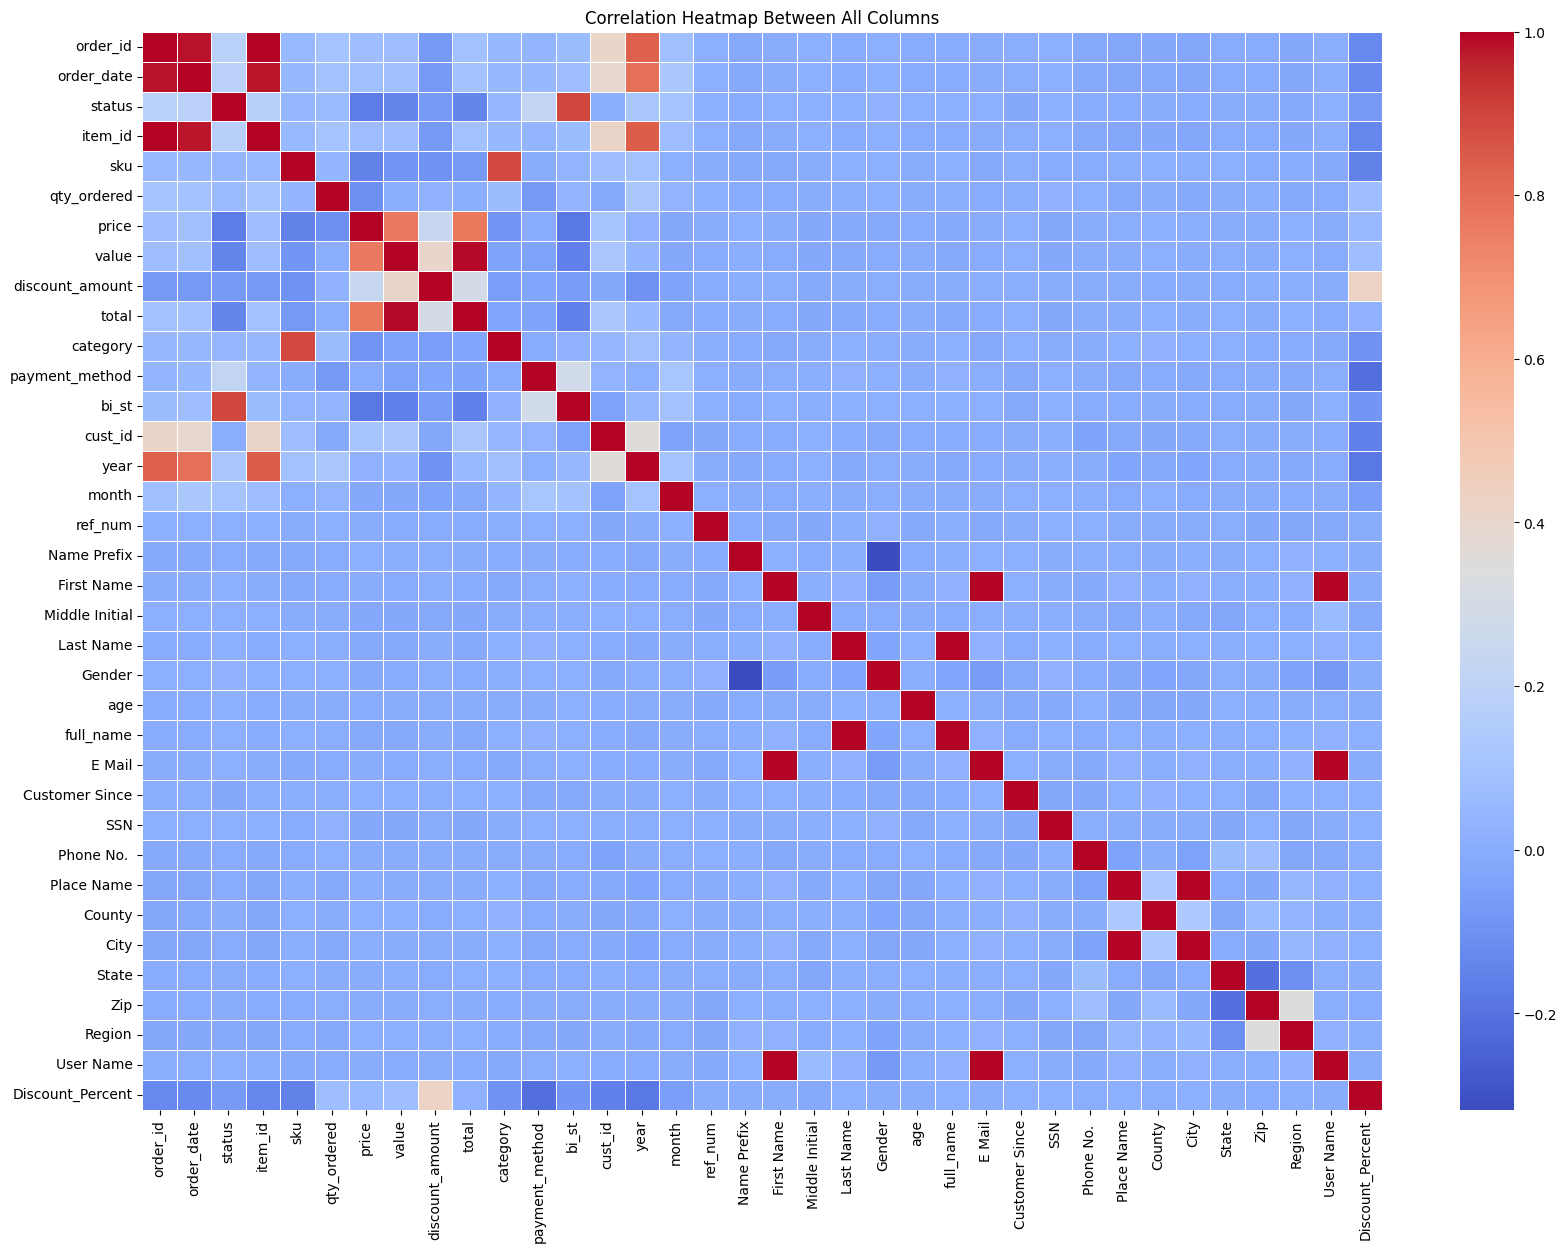

In [103]:
plt.figure(figsize=(20,14))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap Between All Columns")
plt.show()

Separate Important vs Less-Used Columns

In [104]:
model_columns = [
    'cust_id',
    'order_date',
    'transaction_value',
    'qty_ordered',
    'price',
    'category',
    'payment_method',
    'City',
    'State',
    'Region',
    'age',
    'Gender'
]

# Columns not used in modeling
unused_columns = [col for col in df.columns if col not in model_columns]

unused_df = df[unused_columns]

# Save unused columns
unused_df.to_csv("unused_columns_backup.csv", index=False)

print("Unused columns saved separately.")

Unused columns saved separately.


Create Modeling Dataset

In [105]:
# Ensure numeric columns before creating transaction_value
df['qty_ordered'] = pd.to_numeric(df['qty_ordered'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Create transaction_value column
df['transaction_value'] = df['qty_ordered'] * df['price']

model_df = df[model_columns].copy()
model_df.head()

,cust_id,order_date,transaction_value,qty_ordered,price,category,payment_method,City,State,Region,age,Gender
0,60124.0,737699,1887.9,21.0,89.9,8,6,14758,36,2,43.0,0
1,60124.0,737699,209.0,11.0,19.0,8,6,14758,36,2,43.0,0
2,60124.0,737699,1349.1,9.0,149.9,8,6,14758,36,2,43.0,0
3,60124.0,737699,719.1,9.0,79.9,8,6,14758,36,2,43.0,0
4,60124.0,737742,199.8,2.0,99.9,8,6,14758,36,2,43.0,0


Handle Missing Values

In [106]:
# Fill missing numeric values
numeric_cols = model_df.select_dtypes(include=np.number).columns
model_df[numeric_cols] = model_df[numeric_cols].fillna(model_df[numeric_cols].median())

# Fill categorical values
categorical_cols = model_df.select_dtypes(include='object').columns
model_df[categorical_cols] = model_df[categorical_cols].fillna("Unknown")

Create Cutoff Date (Important for CLV)

In [107]:
model_df['order_date'] = pd.to_datetime(model_df['order_date'].apply(lambda x: pd.Timestamp.fromordinal(int(x))))

cutoff_date = model_df['order_date'].max() - pd.Timedelta(days=30)

past_data = model_df[model_df['order_date'] <= cutoff_date]
future_data = model_df[model_df['order_date'] > cutoff_date]

print("Past Data:", past_data.shape)
print("Future Data:", future_data.shape)

Past Data: (273909, 12)
Future Data: (12483, 12)


Create Customer Features (RFM)

In [108]:
snapshot_date = past_data['order_date'].max() + pd.Timedelta(days=1)

rfm = past_data.groupby('cust_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'cust_id': 'count',
    'transaction_value': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']
rfm.reset_index(inplace=True)

rfm.head()

,cust_id,recency,frequency,monetary
0,4.0,158,30,69711.9
1,15.0,202,6,415.1
2,16.0,293,20,29096.8
3,20.0,34,9,58642.2
4,21.0,210,1,126.0


Create Target Variable (Future 30-Day Spend)

In [109]:
future_spend = future_data.groupby('cust_id')['transaction_value'].sum().reset_index()

future_spend.columns = ['cust_id', 'future_spend_30d']

future_spend.head()

,cust_id,future_spend_30d
0,4.0,8488.6
1,20.0,4547.2
2,32.0,18334.8
3,71.0,1672.5
4,163.0,255.0


Merge Features and Target

In [110]:
customer_df = pd.merge(rfm, future_spend, on='cust_id', how='left')

customer_df['future_spend_30d'] = customer_df['future_spend_30d'].fillna(0)

customer_df.head()

,cust_id,recency,frequency,monetary,future_spend_30d
0,4.0,158,30,69711.9,8488.6
1,15.0,202,6,415.1,0.0
2,16.0,293,20,29096.8,0.0
3,20.0,34,9,58642.2,4547.2
4,21.0,210,1,126.0,0.0


Save Customer Level Dataset

In [111]:
customer_df.to_csv("customer_level_dataset.csv", index=False)

print("Customer level dataset saved.")

Customer level dataset saved.


EDA — Basic Statistics

In [112]:
customer_df.describe()

,cust_id,recency,frequency,monetary,future_spend_30d
count,62406.000000,62406.000000,62406.000000,6.240600e+04,6.240600e+04
mean,79014.568375,172.275502,4.389145,7.587461e+03,2.519762e+02
std,25118.558905,82.748887,13.910186,3.694192e+04,1.347404e+04
min,4.000000,1.000000,1.000000,0.000000e+00,0.000000e+00
25%,66885.250000,120.000000,1.000000,2.930000e+02,0.000000e+00
50%,82487.500000,162.000000,2.000000,1.000000e+03,0.000000e+00
75%,98091.750000,249.000000,4.000000,5.148000e+03,0.000000e+00
max,113709.000000,335.000000,2261.000000,3.054498e+06,3.015317e+06


Distribution Plots

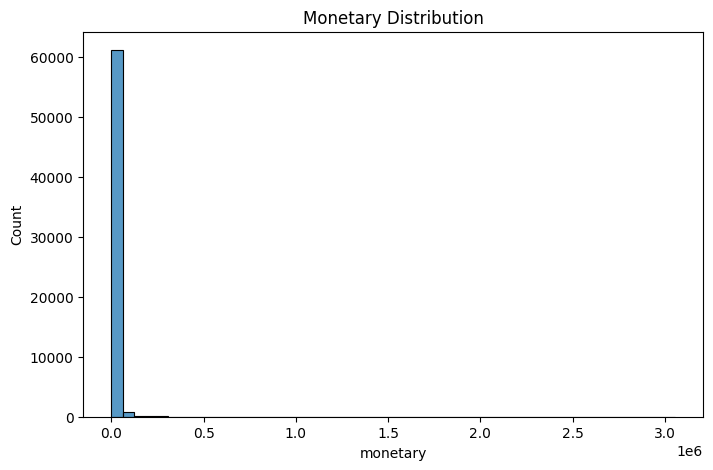

In [113]:
plt.figure(figsize=(8,5))
sns.histplot(customer_df['monetary'], bins=50)
plt.title("Monetary Distribution")
plt.show()

Correlation Analysis

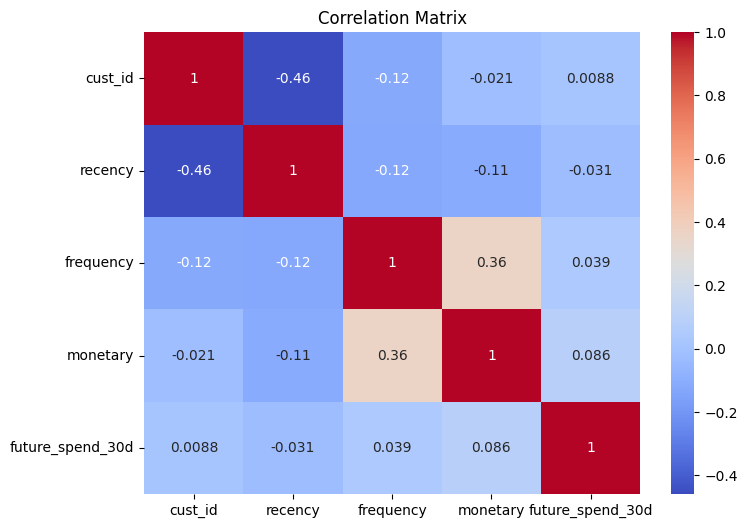

In [114]:
plt.figure(figsize=(8,6))
sns.heatmap(customer_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Install XGBoost

In [115]:
!pip install xgboost

In [116]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

Prepare Data for Model

In [117]:
# Features
X = customer_df[['recency', 'frequency', 'monetary']]

# Target
y = customer_df['future_spend_30d']

Train Test Split

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (49924, 3)
Test Shape: (12482, 3)


Train XGBoost Model

In [119]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Make Predictions

In [120]:
y_pred = xgb_model.predict(X_test)

Model Evaluation

In [121]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost Model Performance")
print("--------------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

XGBoost Model Performance
--------------------------
MAE: 700.661145088631
RMSE: 9926.41446199401
R2 Score: -0.31659858617502934


Feature Importance

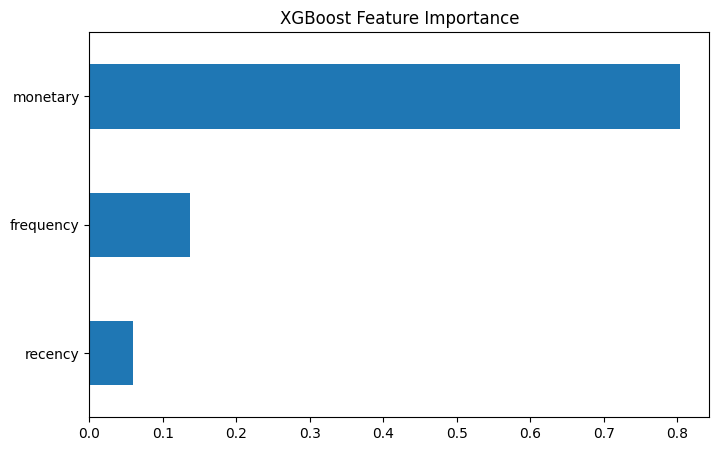

In [122]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("XGBoost Feature Importance")
plt.show()

Save Model

In [123]:
import joblib

joblib.dump(xgb_model, "xgboost_customer_spend_model.pkl")

print("XGBoost model saved successfully")

XGBoost model saved successfully


In [124]:
sample_customer = [[30, 5, 1200]]  # recency, frequency, monetary

prediction = xgb_model.predict(sample_customer)

print("Predicted 30-Day Spend:", prediction[0])

Predicted 30-Day Spend: 228.4912


XGBOOST improvement


In [125]:
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [126]:
# Features
X = customer_df[['recency','frequency','monetary']]

# Target
y = customer_df['future_spend_30d']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Baseline XGBoost
baseline_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)

r2_before = r2_score(y_test, y_pred_base)

print("Baseline R²:", r2_before)

Baseline R²: -0.03963132309962969


Feature Engineering (Better Features)

In [127]:
customer_df['avg_order_value'] = customer_df['monetary'] / customer_df['frequency']
customer_df['avg_order_value'] = customer_df['avg_order_value'].fillna(0)

customer_df['spend_per_day'] = customer_df['monetary'] / (customer_df['recency'] + 1)

customer_df['loyalty_score'] = customer_df['frequency'] * customer_df['monetary']

In [128]:
features = [
    'recency',
    'frequency',
    'monetary',
    'avg_order_value',
    'spend_per_day',
    'loyalty_score'
]

X = customer_df[features]
y = customer_df['future_spend_30d']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Cross Validation

In [129]:
model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R² Scores:", scores)
print("Average CV R²:", scores.mean())

Cross Validation R² Scores: [-1.29917786e+00 -1.14864840e+01 -2.56981544e-01 -2.18069111e-02
 -3.98693837e-03]
Average CV R²: -2.6136874574256863


Hyperparameter Tuning (GridSearch)

In [130]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4,6,8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8,1],
    'colsample_bytree': [0.8,1]
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1}


Train Best Model

In [131]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

Model Evaluation

In [132]:
r2_after = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Improved Model Performance")
print("--------------------------")

print("MAE:", mae)
print("RMSE:", rmse)

print("\nR² BEFORE:", r2_before)
print("R² AFTER:", r2_after)

print("\nImprovement:", r2_after - r2_before)

Improved Model Performance
--------------------------
MAE: 370.96340385822697
RMSE: 7956.410507906649

R² BEFORE: -0.03963132309962969
R² AFTER: 0.15413132920164707

Improvement: 0.19376265230127676


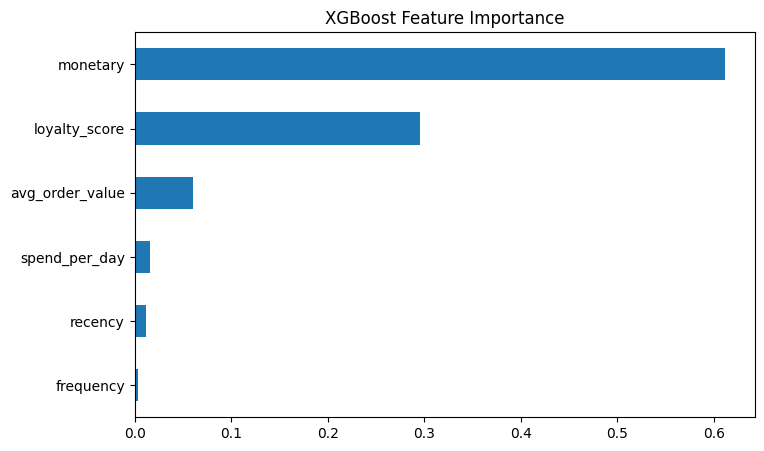

In [133]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("XGBoost Feature Importance")
plt.show()

SHAP Explainability

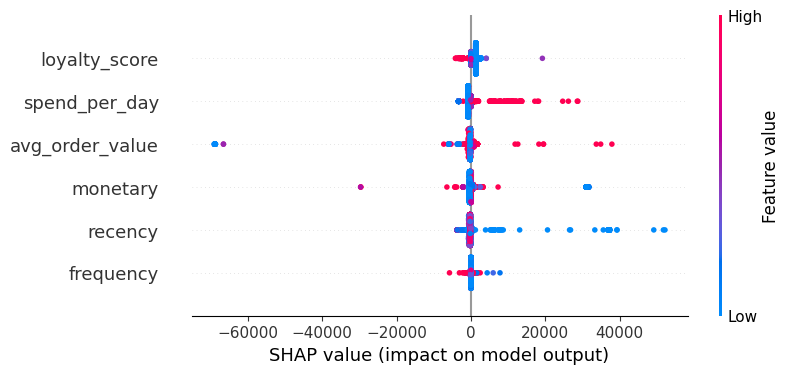

In [134]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

SHAP Feature Importance Plot

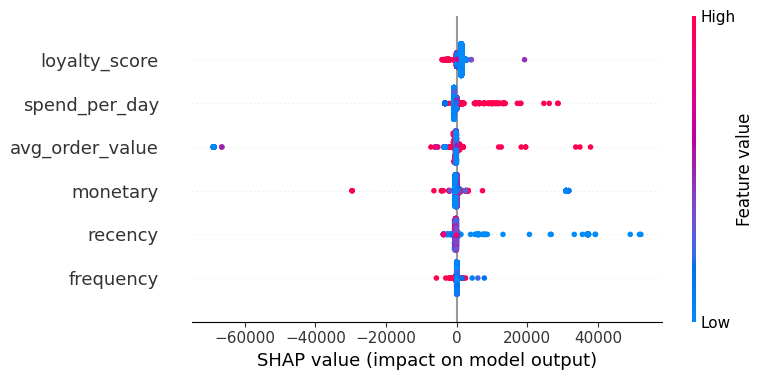

In [135]:
shap.summary_plot(shap_values, X_test)

Save Final Model

In [136]:
import joblib

joblib.dump(best_model, "final_xgboost_model.pkl")

print("Final model saved")

Final model saved


Rows problem solution
